# POD（Proper Orthogonal Decomposition）

这个 notebook 做两件事：

1. 给出一个可直接复用的 POD 函数实现。
2. 用一个二维速度场的合成例子演示如何构造快照矩阵、提取 POD 模态、选择截断阶数并重构流场。

POD 的核心思想是：

- 从一组快照中提取最“重要”的正交空间结构。
- 用尽可能少的模态，保留尽可能多的能量。

如果快照矩阵记为

$$
X = [x_1, x_2, \dots, x_n] \in \mathbb{R}^{m \times n},
$$

其中每一列是一个时刻的状态快照，那么 POD 的标准流程是：

1. 先减去时间平均场，得到中心化矩阵 $X_c$。
2. 如果需要带权内积，则引入权重矩阵 $W = \mathrm{diag}(w_1, \dots, w_m)$。
3. 对加权后的矩阵
   $$
   X_w = W^{1/2} X_c
   $$
   做 SVD：
   $$
   X_w = U_w \Sigma V^T
   $$
4. 还原物理空间中的 POD 模态：
   $$
   \Phi = W^{-1/2} U_w
   $$
5. 模态系数为
   $$
   A = \Phi^T W X_c = \Sigma V^T
   $$
6. 取前 $r$ 个模态后，可以构造截断近似
   $$
   \hat{X}_r = \bar{x} \mathbf{1}^T + \Phi_r A_r
   $$
   这就是低秩重构。

下面先实现函数，再演示一个完整示例。

In [1]:
import numpy as np


def pod(X, weights=None, subtract_mean=True):
    """
    使用 SVD 计算 POD（Proper Orthogonal Decomposition）。

    参数
    ----------
    X : ndarray, shape (m, n)
        快照矩阵。每一列对应一个时间快照。
        m 表示单个快照的自由度数量，n 表示快照数。
    weights : None or ndarray, shape (m,)
        对角权重，对应带权内积 <x, y>_W = x^T W y。
        在 CFD / FVM 场景中，常用网格体积或面积作为权重。
        若为 None，则默认使用欧氏内积，也就是 W = I。
    subtract_mean : bool
        是否先减去时间平均场。POD 在流场分析里通常都建议先去均值，
        这样提取出来的是围绕平均流动的主导涨落结构。

    返回
    -------
    mean : ndarray, shape (m, 1)
        时间平均场。若 subtract_mean=False，则返回零向量。
    Phi : ndarray, shape (m, r)
        POD 模态矩阵。若存在权重，则满足 W-正交归一。
    A : ndarray, shape (r, n)
        模态系数矩阵。第 j 列表示第 j 个快照在各个 POD 模态上的投影系数。
    s : ndarray, shape (r,)
        奇异值。其平方与各模态的能量成正比。
    energy_ratio : ndarray, shape (r,)
        累计能量占比。
    """
    # 转成浮点数组，避免整数输入时影响后续线性代数运算。
    X = np.asarray(X, dtype=float)

    # m: 单个快照的自由度个数；n: 快照数量。
    m, n = X.shape

    # 第一步：构造平均场。
    # keepdims=True 保证 mean 的形状为 (m, 1)，便于后续与 X 广播相减。
    if subtract_mean:
        mean = X.mean(axis=1, keepdims=True)
    else:
        mean = np.zeros((m, 1))

    # 中心化后的快照矩阵 Xc。
    # 它表示“每个快照相对于平均场的偏离”。
    Xc = X - mean

    # 第二步：处理内积权重。
    # 如果没有给权重，就退化成标准欧氏内积。
    if weights is None:
        w = np.ones(m)
    else:
        w = np.asarray(weights, dtype=float).reshape(-1)

        # 权重长度必须与状态维数一致，否则无法定义 W = diag(w)。
        if w.shape[0] != m:
            raise ValueError("weights must have shape (m,)")

        # 对角权重必须为正，否则不能构成合理的能量内积。
        if np.any(w <= 0):
            raise ValueError("all weights must be positive")

    # 第三步：构造加权快照矩阵 Xw = W^{1/2} Xc。
    # 这里的 W 是对角矩阵，所以 W^{1/2} 只需要对每个权重开根号。
    sqrt_w = np.sqrt(w)[:, None]

    # 同样地，后面恢复物理空间模态时需要 W^{-1/2}。
    inv_sqrt_w = 1.0 / sqrt_w

    # 广播乘法等价于左乘一个对角矩阵 W^{1/2}。
    Xw = sqrt_w * Xc

    # 第四步：对加权矩阵做紧致 SVD。
    # Xw = Uw @ diag(s) @ Vt
    # full_matrices=False 会返回更紧致的低秩分解结果。
    Uw, s, Vt = np.linalg.svd(Xw, full_matrices=False)

    # 第五步：把加权空间中的左奇异向量 Uw 映射回物理空间，
    # 得到 POD 模态 Phi = W^{-1/2} Uw。
    Phi = inv_sqrt_w * Uw

    # 第六步：计算模态系数。
    # 理论上有 A = Phi^T W Xc = Sigma V^T。
    # 这里直接用投影公式写出来，便于和数学定义对应。
    A = Phi.T @ (w[:, None] * Xc)

    # 第七步：由奇异值平方得到各模态能量，并计算累计能量占比。
    energy = s**2
    total_energy = np.sum(energy)
    if total_energy == 0:
        raise ValueError("snapshot matrix has zero energy after centering")
    energy_ratio = np.cumsum(energy) / total_energy

    return mean, Phi, A, s, energy_ratio


def choose_r_by_energy(energy_ratio, threshold=0.99):
    """
    根据累计能量阈值选择最小模态数 r。

    例如 threshold=0.99 表示“取最少的模态，使累计能量达到 99%”。
    """
    if not (0 < threshold <= 1):
        raise ValueError("threshold must be in (0, 1]")
    return int(np.searchsorted(energy_ratio, threshold) + 1)


def reconstruct(mean, Phi, A, r):
    """
    使用前 r 个 POD 模态重构快照矩阵。

    数学形式：X_hat = mean + Phi_r @ A_r
    其中 Phi_r 表示前 r 列模态，A_r 表示前 r 行系数。
    """
    return mean + Phi[:, :r] @ A[:r, :]


def relative_reconstruction_error(X, Xhat):
    """
    计算相对 Frobenius 范数重构误差。

    公式：||X - Xhat||_F / ||X||_F
    值越小说明截断 POD 对原始数据的逼近越好。
    """
    denom = np.linalg.norm(X, ord='fro')
    if denom == 0:
        raise ValueError("input matrix X has zero Frobenius norm")
    return np.linalg.norm(X - Xhat, ord='fro') / denom


## 示例：二维速度场的 POD

这个例子构造一个二维速度场 $(u, v)$，并人为加入两个主导相干结构：

- 第一组模态随较低频率振荡，能量更强。
- 第二组模态频率更高，能量较弱。
- 再叠加少量随机噪声，模拟真实数据中的测量误差或小尺度扰动。

构造完速度场后，我们会把每个时刻的二维速度快照展开成一个长向量，再按列拼成快照矩阵：

$$
X =
\begin{bmatrix}
| & | & & | \\
x_1 & x_2 & \cdots & x_n \\
| & | & & |
\end{bmatrix}
$$

其中每个 $x_k$ 同时包含该时刻的 $u$ 和 $v$ 两个速度分量。

这个例子里使用均匀网格，因此权重直接取每个网格单元相同的面积 `dx * dy`。

达到 99% 累计能量所需模态数 r = 2
前 10 个累计能量占比 =
[0.90507  0.999101 0.999107 0.999113 0.999119 0.999125 0.999131 0.999137
 0.999143 0.999149]
相对重构误差 = 1.883370e-02


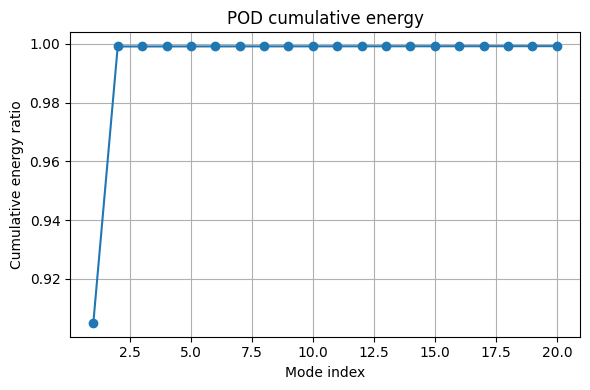

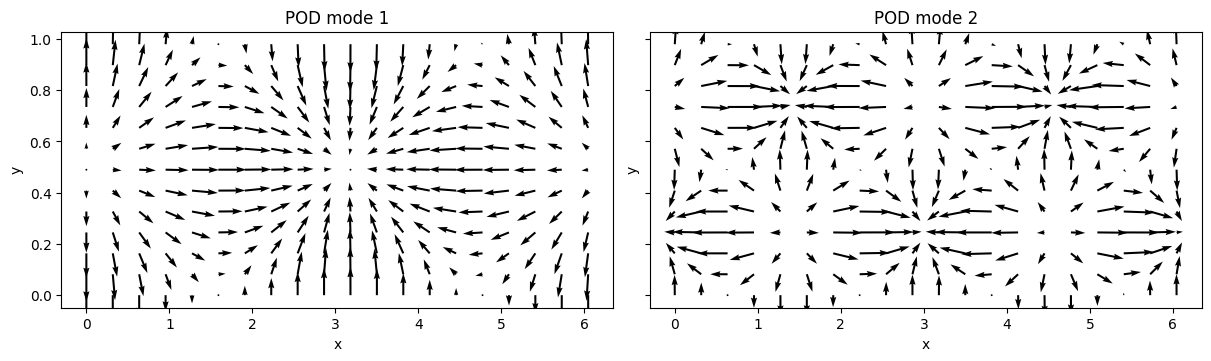

使用前 1 个模态的相对重构误差 = 1.935700e-01
使用前 2 个模态的相对重构误差 = 1.883370e-02
使用前 100 个模态的相对重构误差 = 1.243524e-02


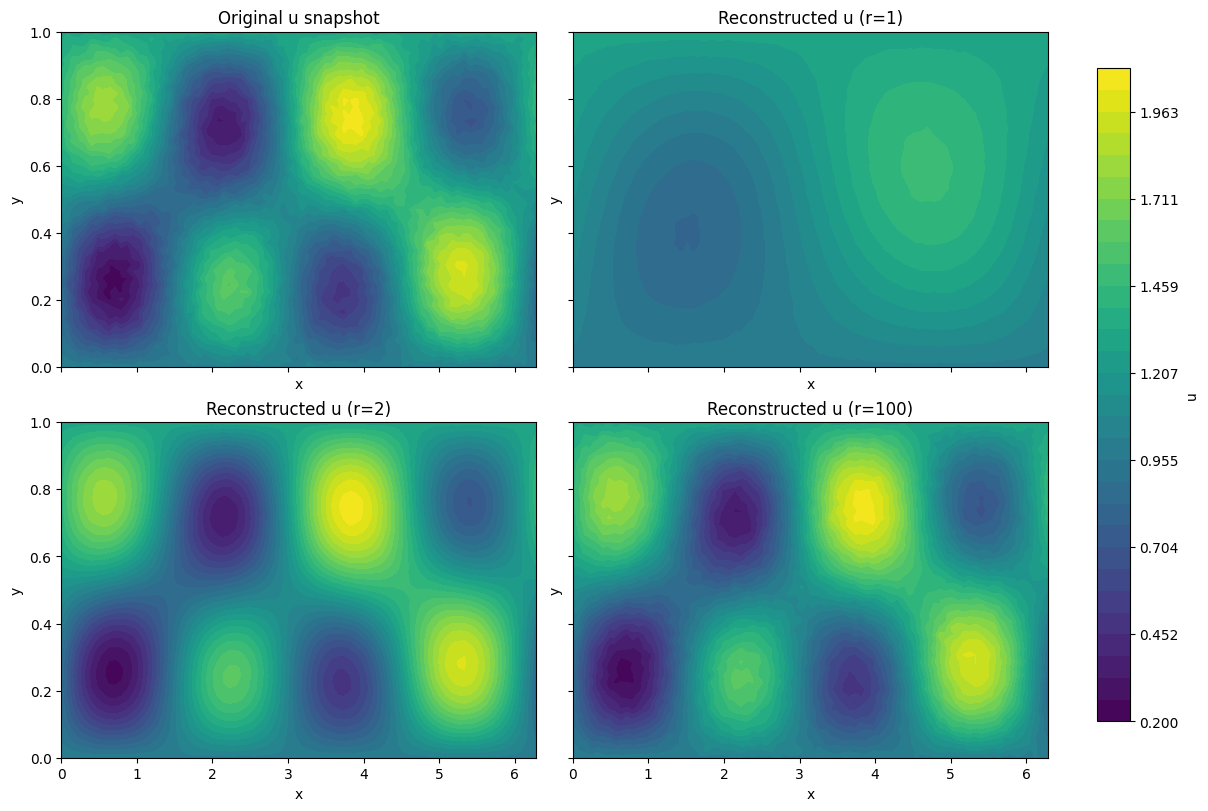

In [2]:
import matplotlib.pyplot as plt

# -----------------------------
# 1) 构造二维空间网格
# -----------------------------
# 这里把 x 方向设置成周期区间 [0, 2pi]，y 方向设置成 [0, 1]。
nx, ny = 80, 50
x = np.linspace(0, 2 * np.pi, nx)
y = np.linspace(0, 1.0, ny)
Xg, Yg = np.meshgrid(x, y)

# 时间上总共取 200 个快照。
n_snap = 200
t = np.linspace(0, 10, n_snap)

# -----------------------------
# 2) 构造平均流场与两个相干结构
# -----------------------------
# 平均流场：u 分量随 y 线性变化，v 分量为 0。
# 这相当于给系统一个稳定背景流。
u_mean = 1.0 + 0.3 * Yg
v_mean = np.zeros_like(Xg)

# 第一组空间结构（能量更强）。
# 在真实流动中，这类结构可以理解为主导的大尺度相干模态。
phi1_u = np.sin(Xg) * np.sin(np.pi * Yg)
phi1_v = -np.cos(Xg) * np.cos(np.pi * Yg)

# 第二组空间结构（能量更弱、频率更高）。
phi2_u = np.sin(2 * Xg + 0.3) * np.sin(2 * np.pi * Yg)
phi2_v = -0.6 * np.cos(2 * Xg + 0.3) * np.cos(2 * np.pi * Yg)

# 固定随机数种子，保证每次运行结果一致，便于教学和复现实验。
rng = np.random.default_rng(0)

# u, v 的形状都为 (n_snap, ny, nx)。
# 第一个维度是时间，后两个维度是空间网格。
u = np.empty((n_snap, ny, nx))
v = np.empty((n_snap, ny, nx))

# 对每个时刻 tk，使用两个时间系数 a1、a2 去调制对应空间结构，
# 再叠加少量噪声，得到完整的速度快照。
for k, tk in enumerate(t):
    a1 = 1.8 * np.sin(2 * np.pi * 0.35 * tk)
    a2 = 0.7 * np.cos(2 * np.pi * 0.95 * tk + 0.4)

    u[k] = u_mean + a1 * phi1_u + a2 * phi2_u + 0.02 * rng.standard_normal((ny, nx))
    v[k] = v_mean + a1 * phi1_v + a2 * phi2_v + 0.02 * rng.standard_normal((ny, nx))

# -----------------------------
# 3) 构造快照矩阵 X
# -----------------------------
# 先把每个时刻的 u、v 展平，再拼接成一个长状态向量：
# x_k = [u_k.flatten(), v_k.flatten()]^T
# 最终得到 X 的形状为 (2 * ny * nx, n_snap)，每一列是一个快照。
Xsnap = np.concatenate(
    [u.reshape(n_snap, -1), v.reshape(n_snap, -1)],
    axis=1
).T

# 对均匀网格来说，每个空间点的权重可以统一取单元面积 dx * dy。
# 由于状态向量里既包含 u 也包含 v，这里对两个分量使用同样的空间权重。
dx = x[1] - x[0]
dy = y[1] - y[0]
weights = np.full(Xsnap.shape[0], dx * dy)

# -----------------------------
# 4) 调用 POD
# -----------------------------
mean, Phi, A, s, energy_ratio = pod(Xsnap, weights=weights, subtract_mean=True)

# 选择能够解释 99% 累计能量的最小模态数。
r99 = choose_r_by_energy(energy_ratio, threshold=0.99)
print(f"达到 99% 累计能量所需模态数 r = {r99}")
print("前 10 个累计能量占比 =")
print(np.round(energy_ratio[:10], 6))

# 用前 r99 个模态对原始快照做低秩重构。
Xhat = reconstruct(mean, Phi, A, r=r99)
err = relative_reconstruction_error(Xsnap, Xhat)
print(f"相对重构误差 = {err:.6e}")

# -----------------------------
# 5) 画累计能量曲线
# -----------------------------
# 这张图用于观察“前几个模态已经捕获了多少能量”。
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, 21), energy_ratio[:20], marker='o')
plt.xlabel("Mode index")
plt.ylabel("Cumulative energy ratio")
plt.title("POD cumulative energy")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 6) 可视化第一、第二 POD 模态
# -----------------------------
# Phi 的前一半对应 u 分量，后一半对应 v 分量。
m_space = ny * nx

# 为了避免箭头太密，这里做稀疏采样。
skip = 4
fig, axes = plt.subplots(
    1, 2, figsize=(12, 3.5), sharex=True, sharey=True, constrained_layout=True
)

for ax, mode_idx in zip(axes, [0, 1]):
    u_mode = Phi[:m_space, mode_idx].reshape(ny, nx)
    v_mode = Phi[m_space:, mode_idx].reshape(ny, nx)
    ax.quiver(
        Xg[::skip, ::skip], Yg[::skip, ::skip],
        u_mode[::skip, ::skip], v_mode[::skip, ::skip]
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"POD mode {mode_idx + 1}")

plt.show()

# -----------------------------
# 7) 对比原始快照与重构快照
# -----------------------------
# 这里挑选第 k=30 个快照，仅查看 u 分量的二维分布。
# 分别比较使用 1、2、3 个模态时的重构结果。
k = 30
u_true = Xsnap[:m_space, k].reshape(ny, nx)

compare_rs = [1, 2, 100]
u_recs = []
for r in compare_rs:
    Xhat_r = reconstruct(mean, Phi, A, r=r)
    err_r = relative_reconstruction_error(Xsnap, Xhat_r)
    print(f"使用前 {r} 个模态的相对重构误差 = {err_r:.6e}")
    u_recs.append(Xhat_r[:m_space, k].reshape(ny, nx))

fields = [u_true, *u_recs]
titles = [
    "Original u snapshot",
    "Reconstructed u (r=1)",
    "Reconstructed u (r=2)",
    "Reconstructed u (r=100)",
]

vmin = min(field.min() for field in fields)
vmax = max(field.max() for field in fields)
levels = np.linspace(vmin, vmax, 31)

fig, axes = plt.subplots(
    2, 2, figsize=(12, 8), sharex=True, sharey=True, constrained_layout=True
)

for ax, field, title in zip(axes.flat, fields, titles):
    contour = ax.contourf(Xg, Yg, field, levels=levels, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.colorbar(contour, ax=axes, shrink=0.9, label="u")
plt.show()


## 误差指标与计算公式

为了更清楚地解释“能量占比”和“重构效果”的关系，下面统计几类常用误差。记

$$
X \in \mathbb{R}^{m \times n}, \quad X_c = X - \bar{x}\mathbf{1}^T, \quad \hat{X}_r = \bar{x}\mathbf{1}^T + \Phi_r A_r,
$$

其中 $X$ 是原始快照矩阵，$X_c$ 是去均值快照矩阵，$\hat{X}_r$ 是使用前 $r$ 个 POD 模态得到的重构。

这里统计以下误差：

1. 原始场相对 Frobenius 误差
   $$
   e_{\mathrm{raw}}^{(r)} = \frac{\|X - \hat{X}_r\|_F}{\|X\|_F}
   $$
2. 去均值场相对 Frobenius 误差
   $$
   e_c^{(r)} = \frac{\|X_c - \Phi_r A_r\|_F}{\|X_c\|_F}
   $$
3. 带权去均值相对误差
   $$
   e_{W,c}^{(r)} = \frac{\|W^{1/2}(X_c - \Phi_r A_r)\|_F}{\|W^{1/2} X_c\|_F}
   = \sqrt{1 - E_r},
   $$
   其中 $E_r = \sum_{i=1}^r s_i^2 / \sum_{i=1}^{r_*} s_i^2$ 是累计能量占比。

4. 平均绝对误差（MAE）
   $$
   \mathrm{MAE}^{(r)} = \frac{1}{mn}\sum_{j=1}^n\sum_{i=1}^m |X_{ij} - \hat{X}_{r,ij}|
   $$
5. 均方根误差（RMSE）
   $$
   \mathrm{RMSE}^{(r)} = \sqrt{\frac{1}{mn}\sum_{j=1}^n\sum_{i=1}^m (X_{ij} - \hat{X}_{r,ij})^2}
   $$
6. 最大绝对误差（MaxAE）
   $$
   \mathrm{MaxAE}^{(r)} = \max_{i,j} |X_{ij} - \hat{X}_{r,ij}|
   $$
7. 第 $k$ 个快照的相对 $L^2$ 误差
   $$
   e_k^{(r)} = \frac{\|x_k - \hat{x}_{r,k}\|_2}{\|x_k\|_2}
   $$

其中第 3 项直接对应 POD 的能量定义，所以它最能解释“为什么能量占比高，但单个快照看起来仍可能差很多”。


In [3]:
# -----------------------------
# 8) 统计不同误差
# -----------------------------
Xc = Xsnap - mean
sqrt_w = np.sqrt(weights)[:, None]


def fro_rel_err(Xref, Xapprox):
    return np.linalg.norm(Xref - Xapprox, ord="fro") / np.linalg.norm(Xref, ord="fro")


def weighted_fro_rel_err(Xref, Xapprox, sqrt_w):
    num = np.linalg.norm(sqrt_w * (Xref - Xapprox), ord="fro")
    den = np.linalg.norm(sqrt_w * Xref, ord="fro")
    return num / den


def mae(Xref, Xapprox):
    return np.mean(np.abs(Xref - Xapprox))


def rmse(Xref, Xapprox):
    return np.sqrt(np.mean((Xref - Xapprox) ** 2))


def maxae(Xref, Xapprox):
    return np.max(np.abs(Xref - Xapprox))


rs_to_report = sorted(set(compare_rs + [r99]))
reconstructions = {r: reconstruct(mean, Phi, A, r=r) for r in rs_to_report}

print("误差统计（全快照矩阵）")
header = (
    f"{'r':>3} {'cumE':>10} {'rel(X)':>12} {'rel(Xc)':>12} "
    f"{'wrel(Xc)':>12} {'MAE':>12} {'RMSE':>12} {'MaxAE':>12}"
)
print(header)
print("-" * len(header))

for r in rs_to_report:
    Xhat_r = reconstructions[r]
    Xc_hat_r = Xhat_r - mean
    print(
        f"{r:>3d} "
        f"{energy_ratio[r - 1]:>10.6f} "
        f"{fro_rel_err(Xsnap, Xhat_r):>12.6e} "
        f"{fro_rel_err(Xc, Xc_hat_r):>12.6e} "
        f"{weighted_fro_rel_err(Xc, Xc_hat_r, sqrt_w):>12.6e} "
        f"{mae(Xsnap, Xhat_r):>12.6e} "
        f"{rmse(Xsnap, Xhat_r):>12.6e} "
        f"{maxae(Xsnap, Xhat_r):>12.6e}"
    )

print()
print(f"第 k={k} 个快照的相对 L2 误差")
header = f"{'r':>3} {'state':>12} {'u-field':>12}"
print(header)
print("-" * len(header))

xk = Xsnap[:, k]
uk = Xsnap[:m_space, k]

for r in rs_to_report:
    Xhat_r = reconstructions[r]
    xhat_k = Xhat_r[:, k]
    uhat_k = Xhat_r[:m_space, k]
    state_rel = np.linalg.norm(xk - xhat_k) / np.linalg.norm(xk)
    u_rel = np.linalg.norm(uk - uhat_k) / np.linalg.norm(uk)
    print(f"{r:>3d} {state_rel:>12.6e} {u_rel:>12.6e}")

print()
effective_rank = int((s > s[0] * 1e-12).sum())
print(f"总模态数 = {len(s)}")
print(f"按 1e-12 相对阈值估计的有效非零模态数 = {effective_rank}")


误差统计（全快照矩阵）
  r       cumE       rel(X)      rel(Xc)     wrel(Xc)          MAE         RMSE        MaxAE
--------------------------------------------------------------------------------------------
  1   0.905070 1.935700e-01 3.081075e-01 3.081075e-01 1.454077e-01 2.039295e-01 7.474620e-01
  2   0.999101 1.883370e-02 2.997780e-02 2.997780e-02 1.582922e-02 1.984165e-02 1.054916e-01
100   0.999608 1.243524e-02 1.979331e-02 1.979331e-02 1.044028e-02 1.310075e-02 6.648193e-02

第 k=30 个快照的相对 L2 误差
  r        state      u-field
-----------------------------
  1 3.226387e-01 2.805703e-01
  2 2.251572e-02 1.644871e-02
100 1.471998e-02 1.067334e-02

总模态数 = 200
按 1e-12 相对阈值估计的有效非零模态数 = 199


## 结果如何解读

运行这个 notebook 后，通常会看到：

- 前两个模态已经解释了绝大部分能量。
- 这与我们构造数据时只注入了两组主导相干结构是一致的。
- 用很少的模态就能把原始快照重构得很好，这正是 POD 的低秩压缩能力。

在真实应用中，POD 常用于：

- 流场降阶建模
- 主导相干结构提取
- 数据压缩与去噪
- ROM（Reduced-Order Model）基底构造

需要注意的是：POD 追求的是“能量最优”，并不直接保证时间动力学最优。若要进一步分析模态的时间演化规律，常常还会结合 DMD、Galerkin 投影或其他动力系统方法。

In [4]:
import numpy as np

# 我们手算过的原始快照矩阵
X_small = np.array([
    [2, 0, 1, 1],
    [1, 1, 2, 0]
], dtype=float)

# 手算里用的权重 W = diag(2, 1)
weights_small = np.array([2.0, 1.0])

mean, Phi, A, s, energy_ratio = pod(
    X_small,
    weights=weights_small,
    subtract_mean=True
)

print("mean =")
print(mean)

print("\nPhi =")
print(Phi)

print("\nA =")
print(A)

print("\ns =")
print(s)

print("\nenergy_ratio =")
print(energy_ratio)

mean =
[[1.]
 [1.]]

Phi =
[[0.70710678 0.        ]
 [0.         1.        ]]

A =
[[ 1.41421356 -1.41421356  0.          0.        ]
 [ 0.          0.          1.         -1.        ]]

s =
[2.         1.41421356]

energy_ratio =
[0.66666667 1.        ]
